# Conditional VAE on CelebA: Generating and Manipulating Faces

In-Class Exercise

---

## The Big Picture

In the MNIST CVAE exercise, we conditioned on **digit labels** (10 mutually exclusive classes). Now we scale up to **CelebA** — real face images conditioned on **40 binary attributes** (Smiling, Eyeglasses, Male, Blond_Hair, etc.).

| | MNIST CVAE | CelebA CVAE |
|---|---|---|
| Image size | 28x28x1 (grayscale) | 64x64x3 (RGB) |
| Condition | 10-class one-hot | 40 binary attributes |
| Latent dim | 32 | 128 |
| Training time | Minutes | ~12 min (30k subset on T4) |

The core concepts (ELBO, reparametrization, beta trade-off) are **identical** — only the scale differs.

### What We'll Do Today
1. Explore CelebA dataset and attribute distributions
2. Build a CelebA Conditional VAE (bigger architecture)
3. Train it on face images with attribute conditions
4. Reconstruct faces and measure quality
5. **Generate faces with specific attributes** (Smiling, Eyeglasses, etc.)
6. Explore the latent space
7. Interpolate between faces and **manipulate attributes**
8. Experiment with the beta hyperparameter

In [ ]:
# @title Setup {display-mode: "form"}

# @markdown Clone the course repo and import helpers. Just run and move on!
# -- Step 1: Clone the course repo (force fresh copy) ---------------------
%cd /content
!rm -rf coding-exercises
!git clone https://github.com/eth-bmai-fs26/coding-exercises.git
%cd coding-exercises
!git checkout conditional_vae
%cd "CVAE CX"

# -- Step 2: Install dependencies -----------------------------------------
!pip install -q datasets

# -- Step 3: Import helpers ------------------------------------------------
from utils import *           # training loops, plotting helpers, DEVICE
from models import *          # CelebAAttributePredictor
from data import *            # load_celeba(), CELEBA_ATTR_NAMES

setup()                       # confirms device (CPU / GPU)

In [22]:
# -- Step 3: Import helpers ------------------------------------------------
from utils import *           # training loops, plotting helpers, DEVICE
from models import *          # CelebAAttributePredictor
from data import *            # load_celeba(), CELEBA_ATTR_NAMES

setup()    

Setup complete. Running on: cpu


---
## Part 1: Exploring the CelebA Dataset

### From Digits to Faces

CelebA contains over 200,000 celebrity face images, each annotated with **40 binary attributes**. Unlike MNIST's mutually exclusive classes, these attributes are **multi-label** — a face can be both "Smiling" AND "Wearing_Lipstick" AND "Young" simultaneously.

We load a subset (30k images) to fit in Colab's memory. The dataset is downloaded from HuggingFace.

In [2]:
X_train, attrs_train, X_test, attrs_test = load_celeba(max_samples=30000)

print(f"\nAttribute names ({len(CELEBA_ATTR_NAMES)}):")
for i, name in enumerate(CELEBA_ATTR_NAMES):
    print(f"  {i:2d}. {name}", end="\t" if (i+1) % 4 != 0 else "\n")

/Users/inl/Desktop/ta/ta_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Generating test split: 100%|██████████| 19867/19867 [00:00<00:00, 98613.77 examples/s]


Processing 30,000 training images...
  processed 5,000/30,000 images...
  processed 10,000/30,000 images...
  processed 15,000/30,000 images...
  processed 20,000/30,000 images...
  processed 25,000/30,000 images...
  processed 30,000/30,000 images...
Processing 10,000 test images...
  processed 5,000/10,000 images...
  processed 10,000/10,000 images...
Training images : (30000, 3, 64, 64)  -> 30,000 images of 64x64x3
Test images     : (10000, 3, 64, 64)   -> 10,000 images of 64x64x3
Attributes      : 40 binary attributes per image

Attribute names (40):
   0. 5_o_Clock_Shadow	   1. Arched_Eyebrows	   2. Attractive	   3. Bags_Under_Eyes
   4. Bald	   5. Bangs	   6. Big_Lips	   7. Big_Nose
   8. Black_Hair	   9. Blond_Hair	  10. Blurry	  11. Brown_Hair
  12. Bushy_Eyebrows	  13. Chubby	  14. Double_Chin	  15. Eyeglasses
  16. Goatee	  17. Gray_Hair	  18. Heavy_Makeup	  19. High_Cheekbones
  20. Male	  21. Mouth_Slightly_Open	  22. Mustache	  23. Narrow_Eyes
  24. No_Beard	  25. Oval_Fac

In [ ]:
# @title Fallback: install datasets if needed {display-mode: "form"}
# @markdown Uncomment and run ONLY if load_celeba() fails with an import error.

# !pip install -q datasets

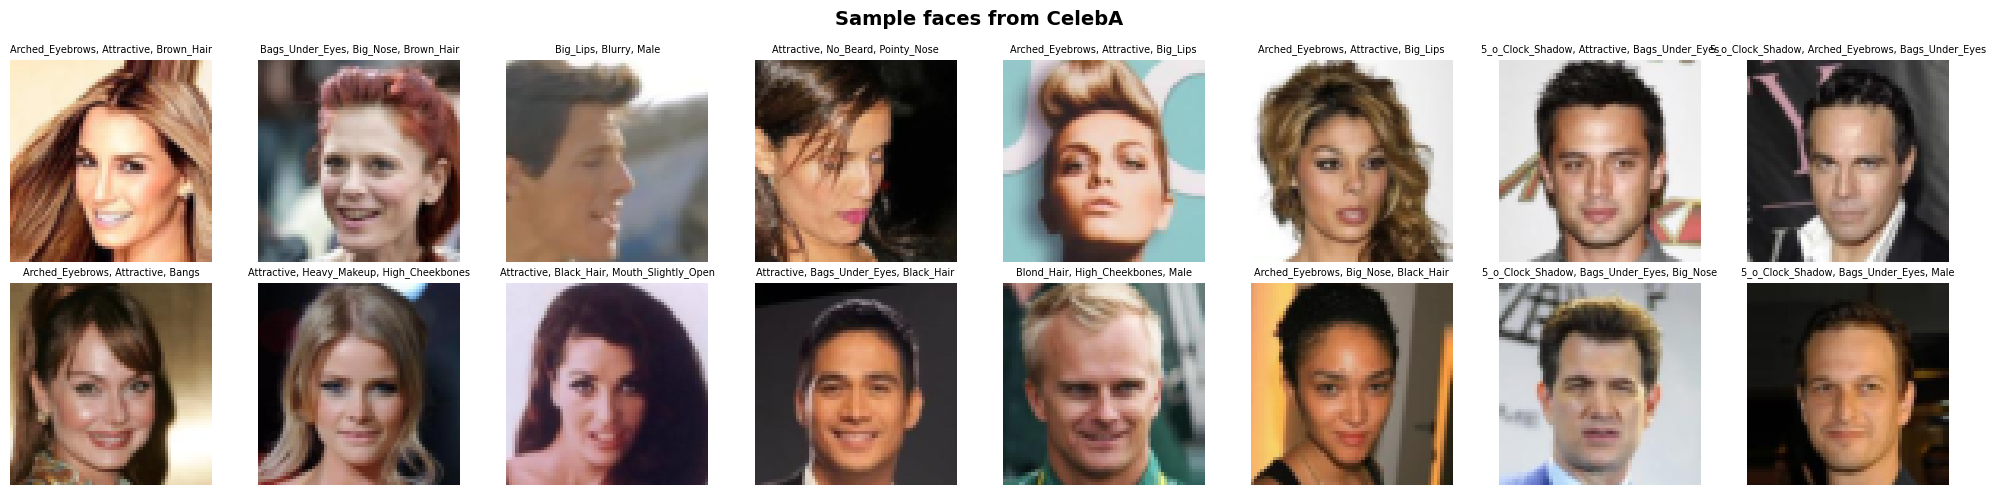

In [3]:
# @title Sample faces from CelebA {display-mode: "form"}

fig, axes = plt.subplots(2, 8, figsize=(20, 5))
fig.suptitle("Sample faces from CelebA", fontsize=14, fontweight='bold')
for i in range(16):
    ax = axes[i // 8, i % 8]
    ax.imshow(np.clip(X_train[i].transpose(1, 2, 0), 0, 1))
    # Show top 3 active attributes
    active = [CELEBA_ATTR_NAMES[j] for j in range(40) if attrs_train[i, j] == 1.0]
    ax.set_title(', '.join(active[:3]), fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.show()

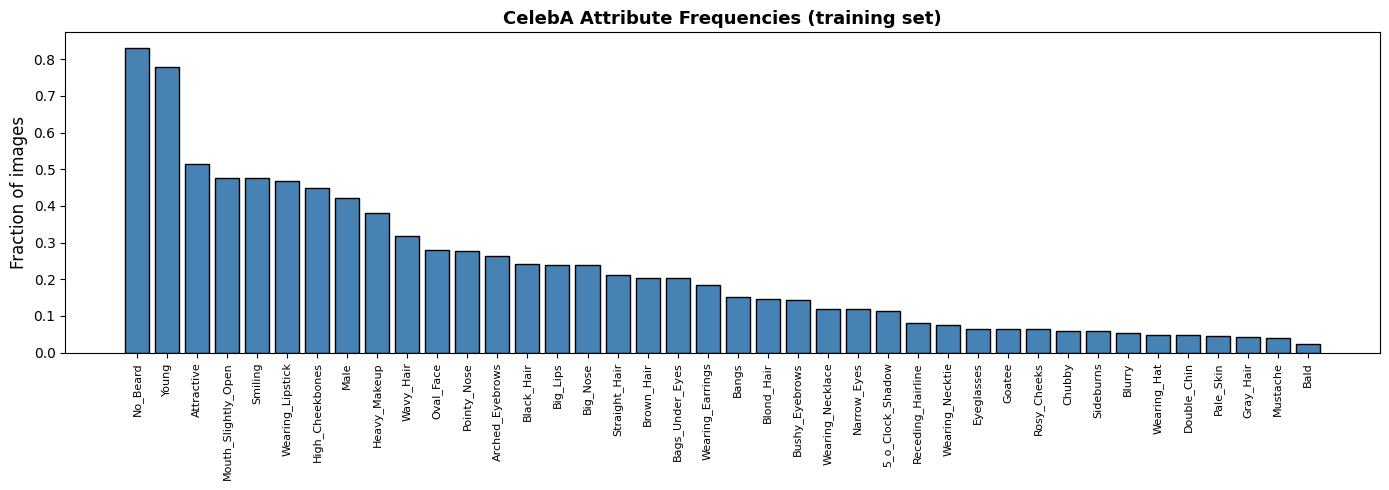

Most common:  No_Beard (83.2%)
Least common: Bald (2.3%)


In [4]:
# @title Attribute frequency distribution {display-mode: "form"}

freq = attrs_train.mean(axis=0)
sorted_idx = np.argsort(freq)[::-1]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(40), freq[sorted_idx], color='steelblue', edgecolor='black')
ax.set_xticks(range(40))
ax.set_xticklabels([CELEBA_ATTR_NAMES[i] for i in sorted_idx],
                   rotation=90, fontsize=8)
ax.set_ylabel('Fraction of images', fontsize=12)
ax.set_title('CelebA Attribute Frequencies (training set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Most common:  {CELEBA_ATTR_NAMES[sorted_idx[0]]} ({freq[sorted_idx[0]]:.1%})")
print(f"Least common: {CELEBA_ATTR_NAMES[sorted_idx[-1]]} ({freq[sorted_idx[-1]]:.1%})")

---
## Part 2: Understanding the CelebA CVAE Architecture

### Scaling Up from MNIST

The architecture is a faithful PyTorch translation of [EleMisi/ConditionalVAE](https://github.com/EleMisi/ConditionalVAE):

| Component | MNIST | CelebA |
|---|---|---|
| Encoder input | (11, 28, 28) | (43, 64, 64) |
| Conv blocks (encoder) | 3 (stride 2, 2, 1) | 4 (all stride 2) |
| Filter counts | 32, 64, 128 | 32, 64, 128, 256 |
| Kernel size | 3x3 | 3x3 |
| Spatial reduction | 28->14->7 | 64->32->16->8->4 |
| FC latent layer | Two heads: fc_mu, fc_log_var | One fc_latent -> 2*latent_dim, then split |
| Latent dim | 32 | 128 |
| Decoder bottleneck | 128ch at 7x7 | 256ch at 4x4 |
| Decoder blocks | 4 (all stride-2) | 5: 4x stride-2 + 1x stride-1 refinement |
| Decoder filters | 128, 64, 32, 1 | 256, 128, 64, 32, 3 |
| Decoder input | z(32)+label(10) = 42 | z(128)+attrs(40) = 168 |

**Conditioning is identical to MNIST:**
- **Encoder:** broadcast 40 attribute channels spatially, concatenate with image -> (43, 64, 64)
- **Decoder:** concatenate z with attribute vector -> (168,)

**Two architecture differences from MNIST to note:**
1. The encoder has a single `fc_latent` that outputs `2 * latent_dim`, then is split into `mu` and `log_var` — matching EleMisi's original `Dense(2*latent_dim)` + split pattern.
2. The decoder has an extra stride-1 `ConvTranspose2d(32->3)` refinement block at the end, after four stride-2 upsamplings.

### The Loss Function (ELBO)

The loss function is **dataset-agnostic** — the same BCE + KL formula works for MNIST (1x28x28) and CelebA (3x64x64).

---
### TODO 1 — Complete the CelebAConvCVAE class

The `__init__` defines all layers. Your task is to fill in the methods:

**`conditional_input(self, x, label)`** — Prepare the encoder input:
1. Reshape `label` from `(B, 40)` to `(B, 40, 1, 1)`
2. Expand to `(B, 40, 64, 64)` using `.expand()`
3. Concatenate with `x` along the channel dimension -> `(B, 43, 64, 64)`

**`reparametrize(self, mu, log_var)`** — The reparametrization trick:
1. Compute `std = exp(0.5 * log_var)`
2. Sample `eps` from N(0, I) with the same shape as `std`
3. Return `mu + std * eps`

**`encode(self, x, label)`** — Encoder forward pass:
1. Build conditional input
2. Pass through `self.encoder_conv`, flatten
3. Pass through `self.fc_latent` -> vector of size `2 * latent_dim`
4. Split: `mu = out[:, :latent_dim]`, `log_var = out[:, latent_dim:]`
5. Return `mu, log_var`

**`decode(self, z, label)`** — Decoder forward pass:
1. Concatenate `z` and `label` along dim=1 -> `(B, latent_dim + 40)`
2. Pass through `self.decoder_fc`, reshape to `(B, 256, 4, 4)`, then through `self.decoder_conv`

**`forward(self, x, label)`** — Full CVAE pass:
1. Encode -> reparametrize -> decode
2. Return `recon_x, mu, log_var`

In [5]:
class CelebAConvCVAE(nn.Module):
    """
    Convolutional Conditional VAE for CelebA.
    Faithful PyTorch translation of EleMisi/ConditionalVAE.
    Encoder: (43, 64, 64) -> mu, log_var  (latent_dim each)
    Decoder: (latent_dim + 40) -> (3, 64, 64)
    """
    def __init__(self, latent_dim=128, label_dim=40):
        super().__init__()
        self.latent_dim = latent_dim
        self.label_dim  = label_dim

        # -- ENCODER --------------------------------------------------------
        # 4 conv blocks: 32->64->128->256, 3x3 kernels, stride 2
        # Spatial: 64->32->16->8->4
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(3 + label_dim, 32,  3, stride=2, padding=1),  # -> (32,  32, 32)
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            nn.Conv2d(32,  64,  3, stride=2, padding=1),            # -> (64,  16, 16)
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64,  128, 3, stride=2, padding=1),            # -> (128,  8,  8)
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 3, stride=2, padding=1),            # -> (256,  4,  4)
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
        )
        # Single linear: outputs mu and log_var concatenated, split in encode()
        self.fc_latent = nn.Linear(256 * 4 * 4, latent_dim * 2)

        # -- DECODER --------------------------------------------------------
        # 5 conv blocks: 4x stride-2 upsamplings + 1x stride-1 refinement
        # Spatial: 4->8->16->32->64->64
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim + label_dim, 256 * 4 * 4),
            nn.LeakyReLU(0.2),
        )
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(256, 256, 3, stride=2, padding=1, output_padding=1),  # -> (256, 8, 8)
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(256, 128, 3, stride=2, padding=1, output_padding=1),  # -> (128, 16, 16)
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(128, 64,  3, stride=2, padding=1, output_padding=1),  # -> (64,  32, 32)
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(64,  32,  3, stride=2, padding=1, output_padding=1),  # -> (32,  64, 64)
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(32,   3,  3, stride=1, padding=1),                    # -> (3,   64, 64)
            nn.Sigmoid(),
        )

    # --- TODO 1a: Conditional input ---
    def conditional_input(self, x, label):
        """Concatenate attribute vector (broadcast spatially) with the image."""
        # SOLUTION
        label_map = label.unsqueeze(-1).unsqueeze(-1)               # (B, 40, 1, 1)
        label_map = label_map.expand(-1, -1, x.size(2), x.size(3)) # (B, 40, 64, 64)
        return torch.cat([x, label_map], dim=1)                     # (B, 43, 64, 64)

    # --- TODO 1b: Reparametrization trick ---
    def reparametrize(self, mu, log_var):
        """Sample z = mu + std * eps, where eps ~ N(0, I)."""
        # SOLUTION
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + std * eps

    # --- TODO 1c: Encode ---
    def encode(self, x, label):
        """Encode image + attributes -> (mu, log_var)."""
        # SOLUTION
        cond = self.conditional_input(x, label)
        h    = self.encoder_conv(cond).flatten(1)
        out  = self.fc_latent(h)
        mu      = out[:, :self.latent_dim]
        log_var = out[:, self.latent_dim:]
        return mu, log_var

    # --- TODO 1d: Decode ---
    def decode(self, z, label):
        """Decode latent z + attributes -> reconstructed image."""
        # SOLUTION
        z_cond = torch.cat([z, label], dim=1)  # (B, latent_dim + 40)
        h = self.decoder_fc(z_cond)
        h = h.view(-1, 256, 4, 4)
        return self.decoder_conv(h)

    # --- TODO 1e: Forward pass ---
    def forward(self, x, label):
        """Full CVAE pass: encode -> reparametrize -> decode."""
        # SOLUTION
        mu, log_var = self.encode(x, label)
        z           = self.reparametrize(mu, log_var)
        recon_x     = self.decode(z, label)
        return recon_x, mu, log_var

In [6]:
LATENT_DIM = 128
cvae = CelebAConvCVAE(latent_dim=LATENT_DIM).to(DEVICE)
total_params = sum(p.numel() for p in cvae.parameters())
print(f"CelebAConvCVAE created: {total_params:,} parameters on {DEVICE}")

CelebAConvCVAE created: 9,038,211 parameters on cpu


---
### TODO 2 — Complete the CVAE loss function

The loss is **identical** to the MNIST version — it operates per-pixel-per-channel and is agnostic to image dimensions.

**Reconstruction loss (BCE):** `F.binary_cross_entropy(recon_x, x, reduction='sum') / batch_size`

**KL divergence:** $D_{KL} = -\frac{1}{2} \sum(1 + \log\sigma^2 - \mu^2 - \sigma^2)$

**Total loss:** `recon_loss + beta * kl_loss`

In [7]:
def cvae_loss(recon_x, x, mu, log_var, beta=1.0):
    """
    Compute the CVAE loss = Reconstruction (BCE) + beta * KL divergence.

    Returns
    -------
    total_loss, recon_loss, kl_loss
    """
    batch_size = x.size(0)

    # TODO 2a: Reconstruction loss (BCE, summed over pixels, averaged over batch)
    # SOLUTION
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum') / batch_size

    # TODO 2b: KL divergence (averaged over batch)
    # SOLUTION
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / batch_size

    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss

---
### Training the CelebA CVAE

Key hyperparameters:
- `latent_dim = 128` — faces need more capacity than digits
- `beta = 1.0` — standard VAE weighting
- `batch_size = 64` — larger images need smaller batches on GPU
- `epochs = 25` — ~12 minutes on Colab T4

> **Note:** CelebA training takes longer than MNIST. You'll see the loss decrease steadily. Generated faces will be somewhat blurry — this is a well-known VAE limitation that motivates GANs and diffusion models.

In [8]:
print("Training CelebA Conditional VAE...")
cvae, loss_history = train_cvae_celeba(cvae, cvae_loss, X_train, attrs_train,
                                       epochs=25, batch_size=64, lr=1e-3, beta=0.65)

Training CelebA Conditional VAE...
  Epoch   1/25 -- Total: 2030245029.68  Recon: 6789.39  KL: 2030238259.20  (lr=0.00100)
  Epoch   5/25 -- Total: 6368.37  Recon: 6264.16  KL: 104.21  (lr=0.00090)
  Epoch  10/25 -- Total: 6319.25  Recon: 6210.74  KL: 108.51  (lr=0.00065)
  Epoch  15/25 -- Total: 6298.01  Recon: 6187.81  KL: 110.20  (lr=0.00035)
  Epoch  20/25 -- Total: 6281.51  Recon: 6170.10  KL: 111.40  (lr=0.00010)
  Epoch  25/25 -- Total: 6274.11  Recon: 6162.10  KL: 112.01  (lr=0.00000)
Training complete!


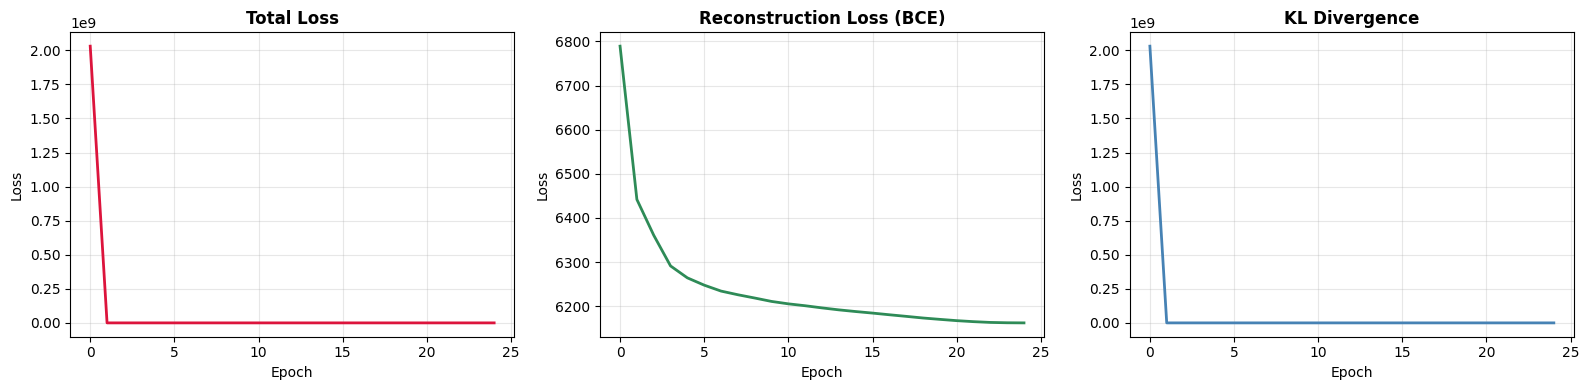

In [9]:
plot_losses(loss_history)

You should see:
- **Total loss** decreasing overall
- **Reconstruction loss** decreasing steadily
- **KL loss** increasing initially then stabilising (latent space regularisation)

---
## Part 3: Reconstruction Quality

### How Well Does It Reconstruct Faces?

VAE reconstructions of faces will be **blurrier** than MNIST reconstructions. This is expected — faces have much more high-frequency detail, and the KL regularisation smooths the latent space at the cost of fine details.

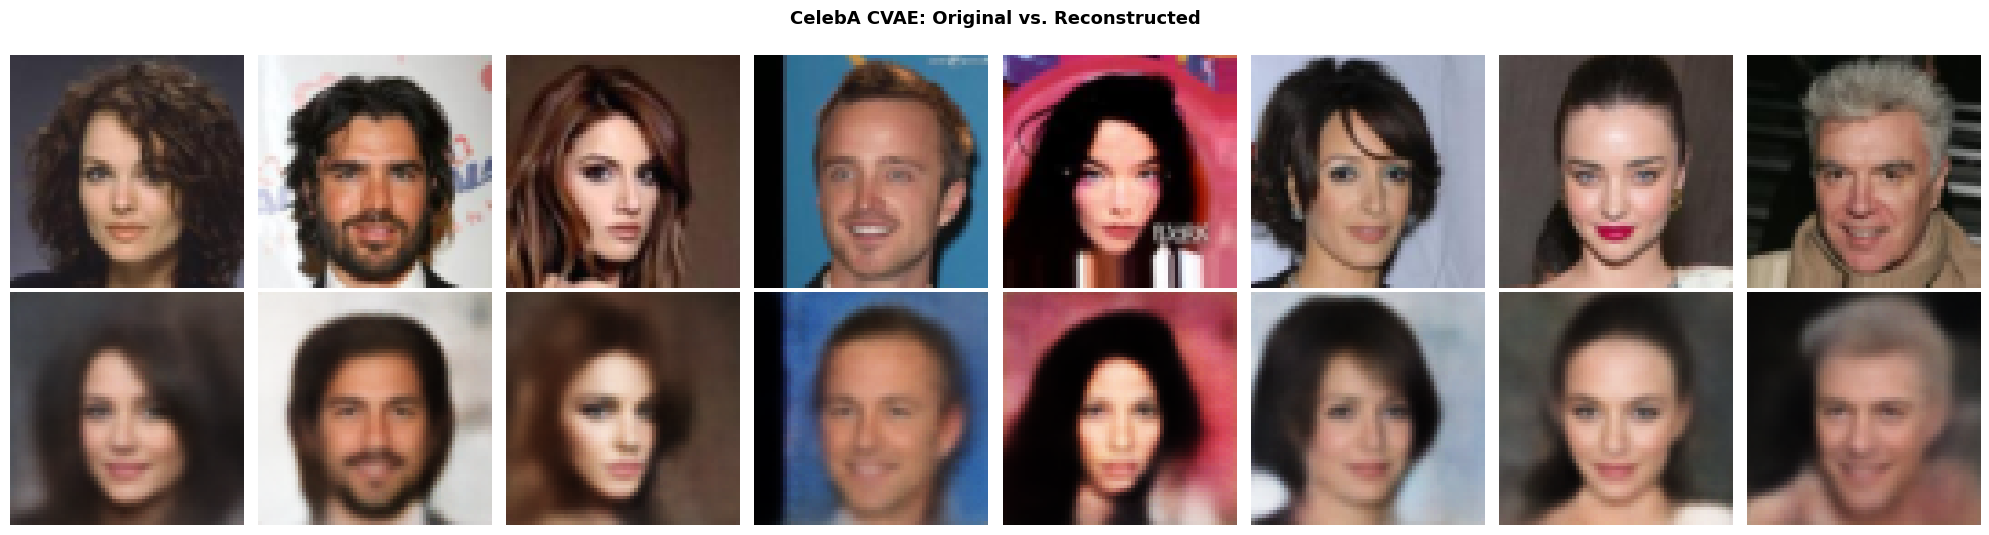

In [10]:
recon = reconstruct_cvae_celeba(cvae, X_test[:100], attrs_test[:100])
plot_original_vs_reconstructed_celeba(X_test[:100], recon,
                                      title="CelebA CVAE: Original vs. Reconstructed")

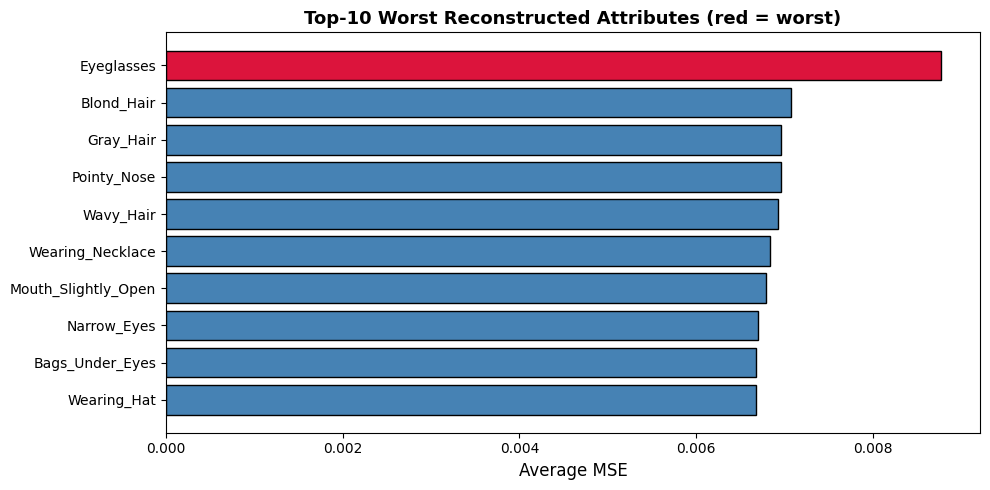


Worst reconstructed attribute: Eyeglasses (MSE = 0.00877)


In [11]:
# @title Per-attribute reconstruction error {display-mode: "form"}
attr_mse = plot_per_attribute_mse(recon, X_test[:100], attrs_test[:100], CELEBA_ATTR_NAMES)

### Debrief

Faces are recognisable but soft. Rare attributes (Bald, Wearing_Hat) are typically harder to reconstruct because the model sees fewer examples during training.

---
## Part 4: Conditional Generation — Generating Faces on Demand

This is the CelebA CVAE's superpower. We can generate faces with **any combination of attributes** by:
1. Sampling z from N(0, I)
2. Choosing desired attributes (e.g., Smiling + Eyeglasses)
3. Feeding both to the decoder

With 40 binary attributes, there are 2^40 possible combinations — the model must generalise to unseen combos!

---
### TODO 3 — Generate faces conditionally

Use `generate_conditional_celeba(model, attrs_dict, attr_names, n, latent_dim)` to generate faces with specific attributes. Try different combinations and observe the variety.

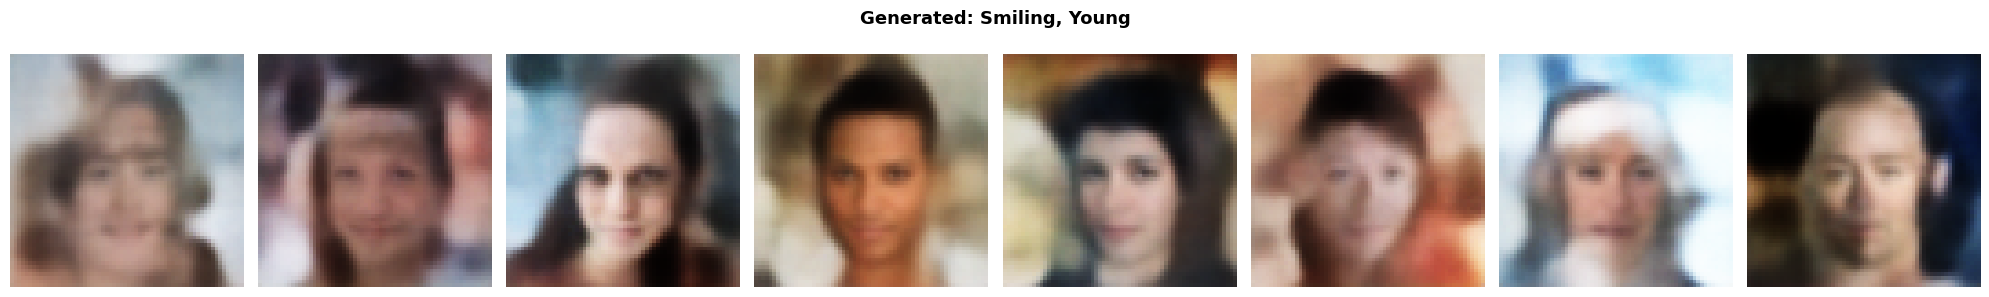

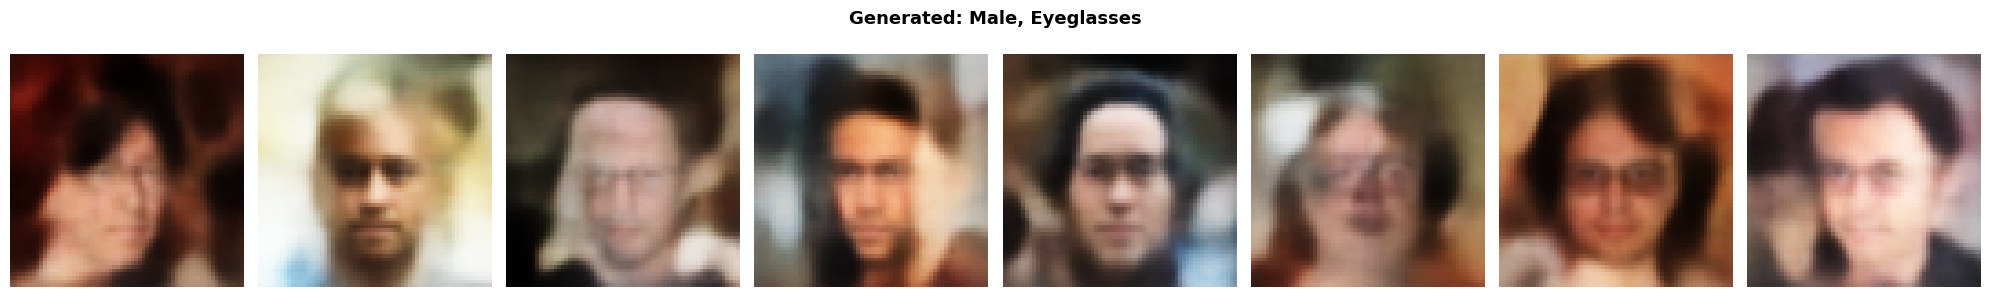

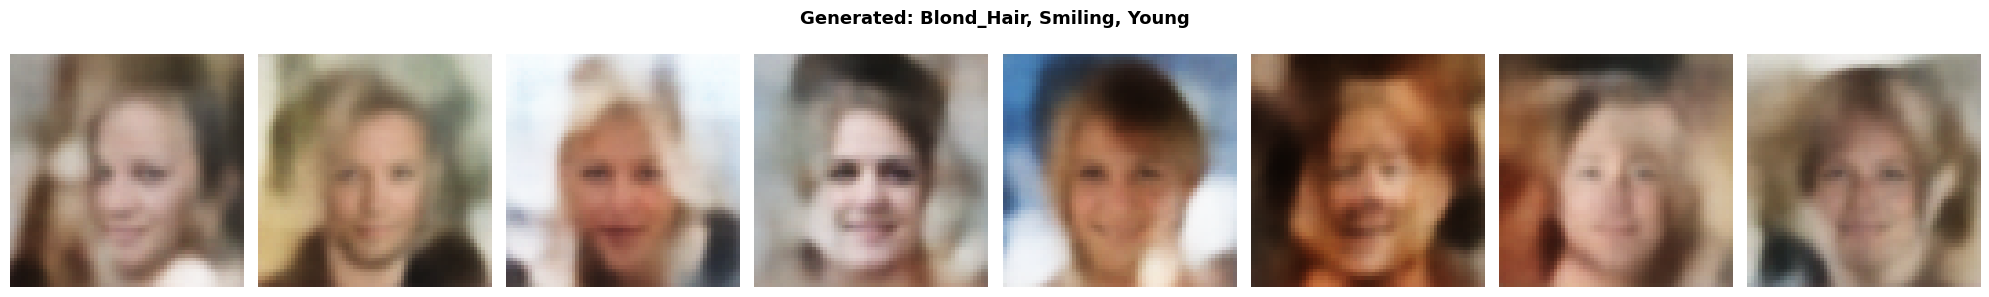

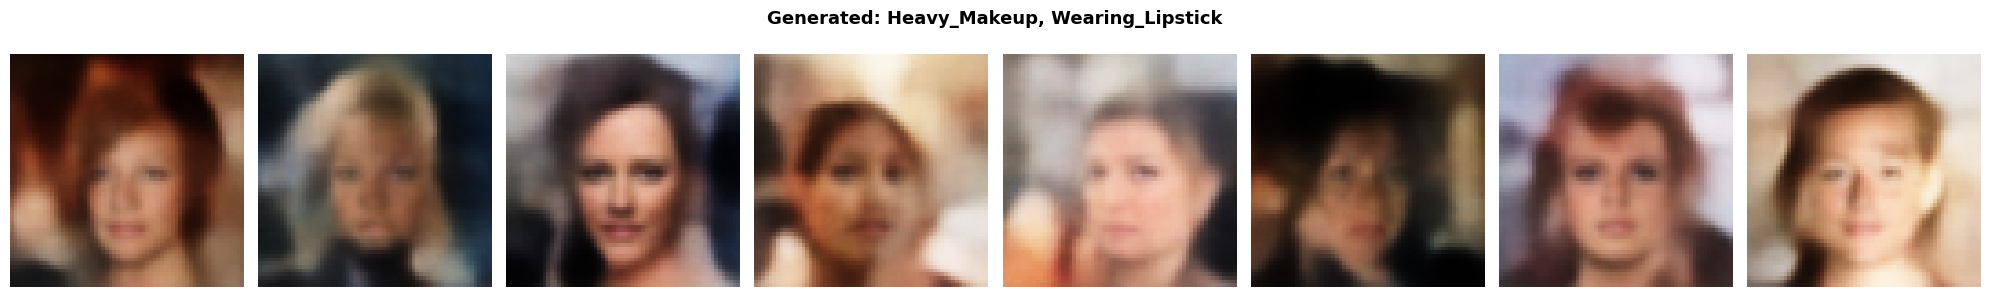

array([[[[0.1143247 , 0.09972689, 0.10774036, ..., 0.24814256,
          0.22793148, 0.23275802],
         [0.11259707, 0.10821781, 0.11036923, ..., 0.24395545,
          0.24165042, 0.22582428],
         [0.10931566, 0.11095116, 0.11420789, ..., 0.27740595,
          0.2532861 , 0.2382754 ],
         ...,
         [0.09152803, 0.092223  , 0.09332926, ..., 0.5645022 ,
          0.55003875, 0.5195842 ],
         [0.09056237, 0.08789551, 0.08790129, ..., 0.57035726,
          0.5608213 , 0.5238463 ],
         [0.0866043 , 0.08703458, 0.0846765 , ..., 0.5687374 ,
          0.5639911 , 0.5287486 ]],

        [[0.06123959, 0.04771317, 0.05434721, ..., 0.11986472,
          0.11376837, 0.12936299],
         [0.05254598, 0.04914565, 0.04829107, ..., 0.1228756 ,
          0.12050057, 0.12182231],
         [0.05343611, 0.05229991, 0.05480098, ..., 0.14128435,
          0.13143113, 0.13578205],
         ...,
         [0.09061284, 0.08891931, 0.10106284, ..., 0.45640197,
          0.443106  , 0.4

In [12]:
# SOLUTION
generate_conditional_celeba(cvae, {"Smiling": 1, "Young": 1}, CELEBA_ATTR_NAMES,
                            n=8, latent_dim=LATENT_DIM)

generate_conditional_celeba(cvae, {"Male": 1, "Eyeglasses": 1}, CELEBA_ATTR_NAMES,
                            n=8, latent_dim=LATENT_DIM)

generate_conditional_celeba(cvae, {"Blond_Hair": 1, "Smiling": 1, "Young": 1}, CELEBA_ATTR_NAMES,
                            n=8, latent_dim=LATENT_DIM)

generate_conditional_celeba(cvae, {"Male": 0, "Heavy_Makeup": 1, "Wearing_Lipstick": 1}, CELEBA_ATTR_NAMES,
                            n=8, latent_dim=LATENT_DIM)

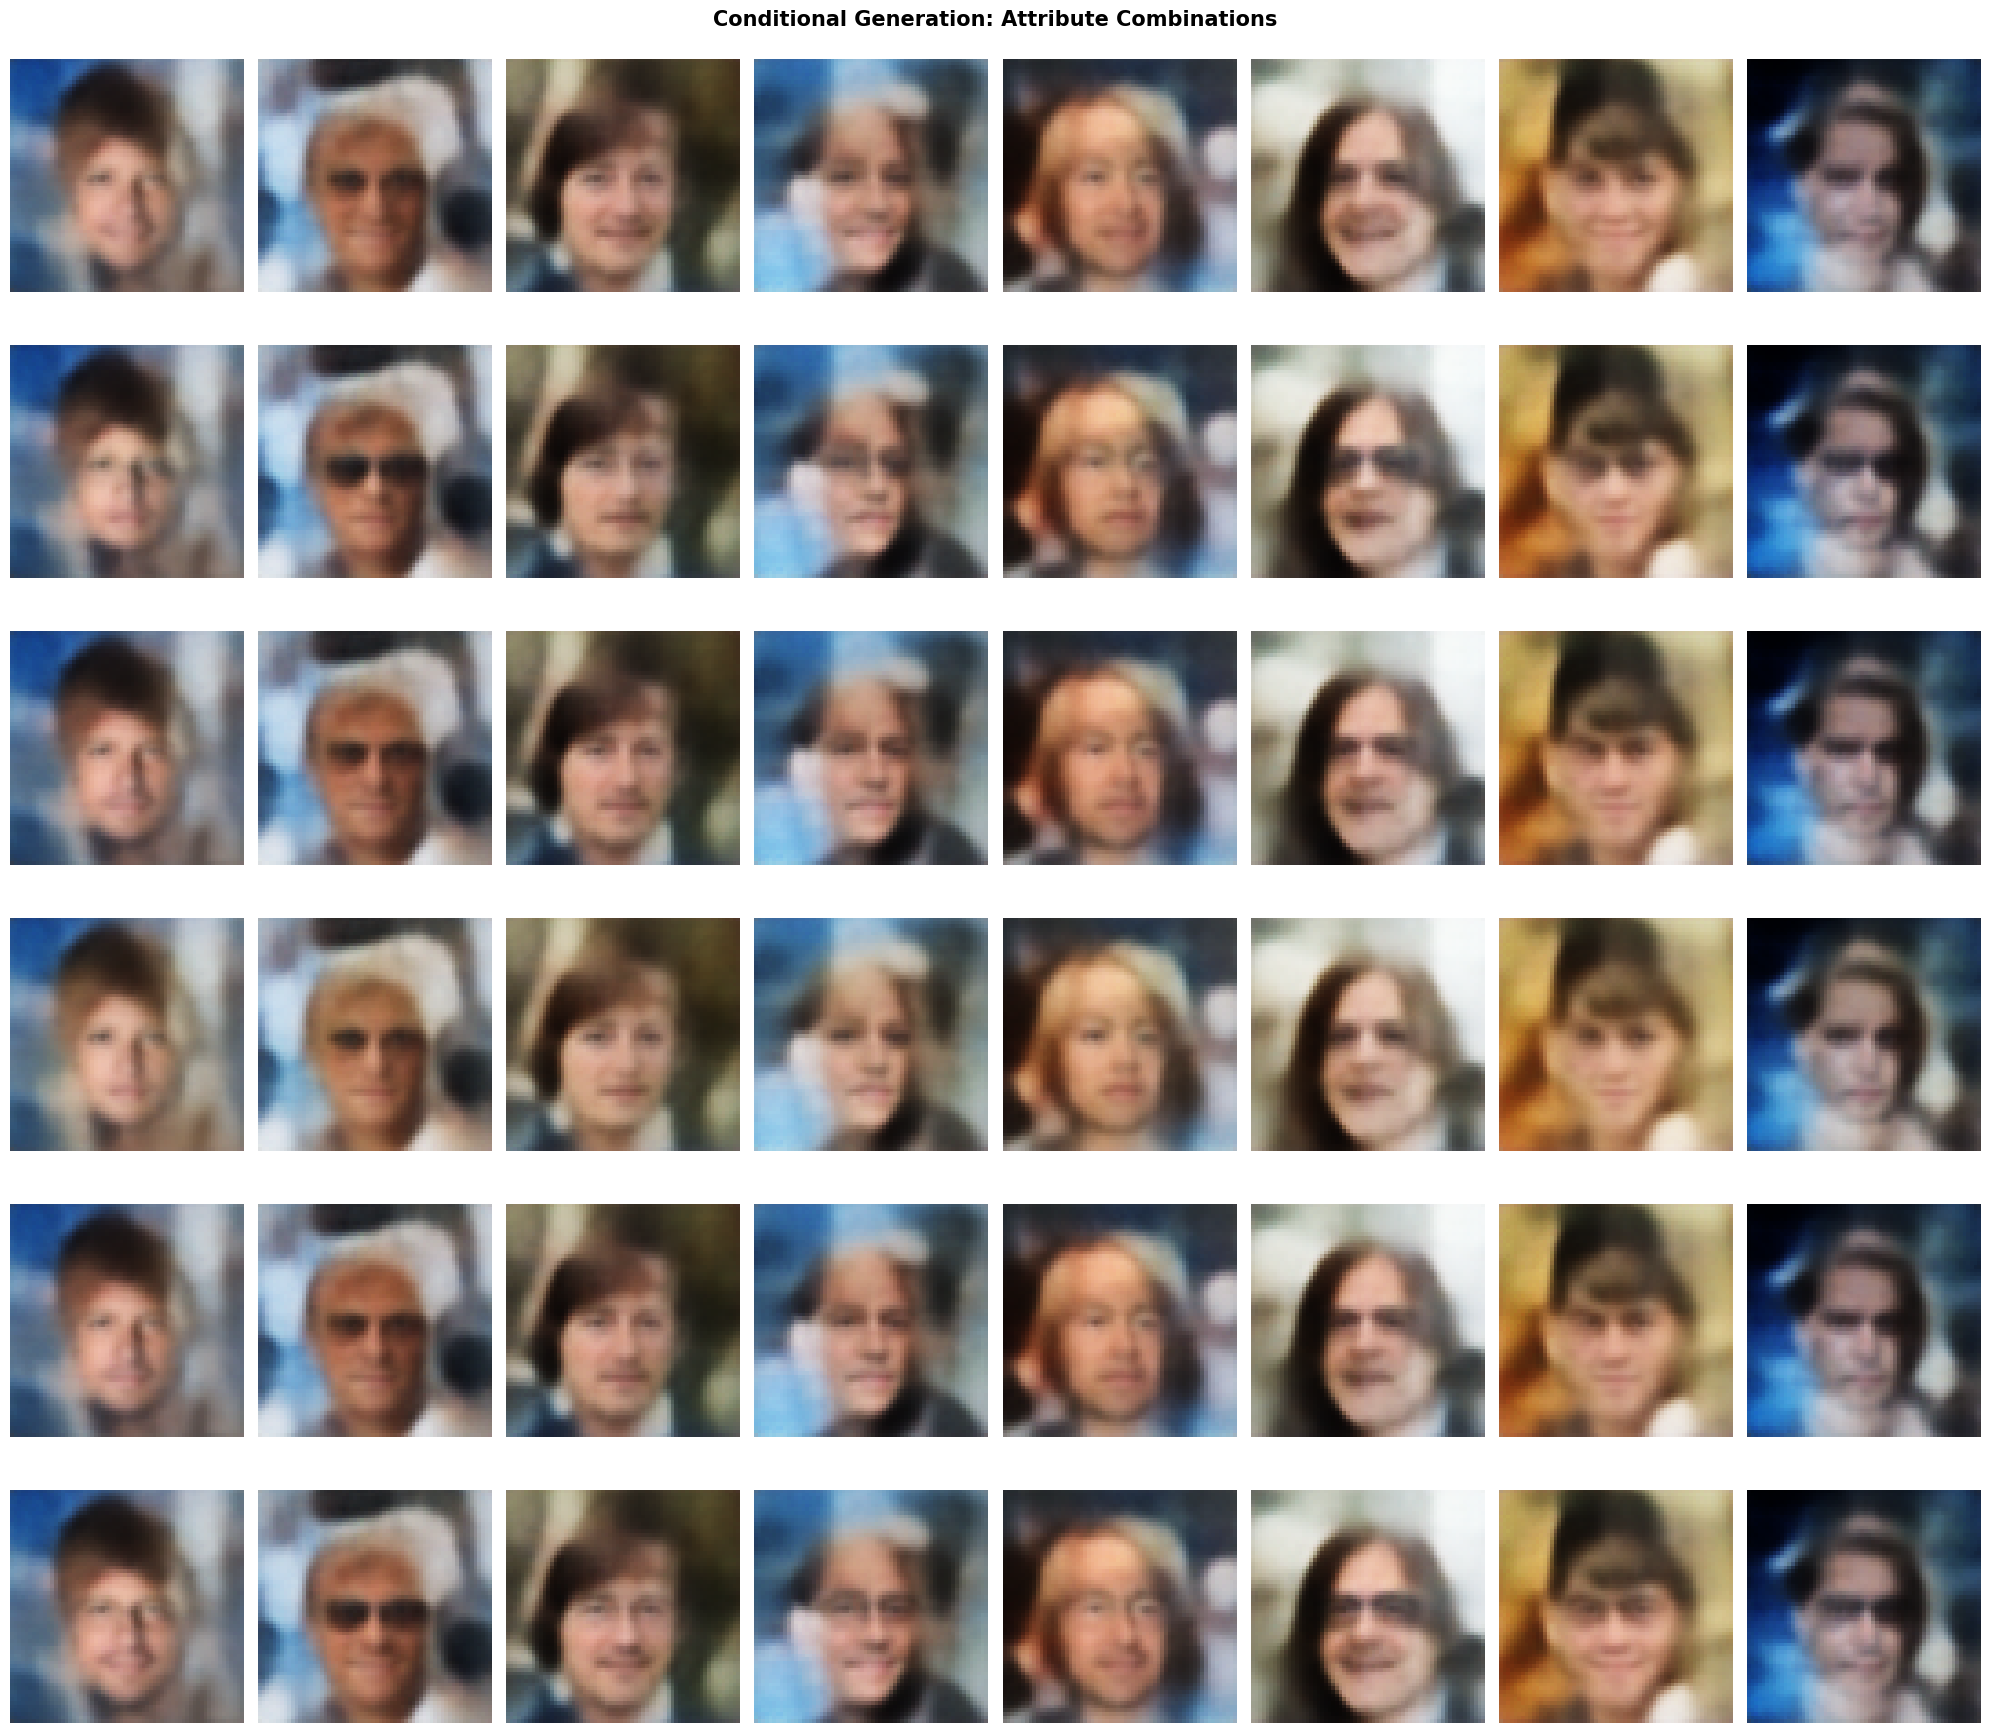

In [13]:
# @title Attribute combination grid {display-mode: "form"}
combos = [
    {"Smiling": 1},
    {"Eyeglasses": 1},
    {"Male": 1},
    {"Blond_Hair": 1, "Young": 1},
    {"Male": 1, "Bald": 1},
    {"Smiling": 1, "Eyeglasses": 1, "Male": 1},
]
generate_attribute_grid(cvae, CELEBA_ATTR_NAMES, combos,
                        latent_dim=LATENT_DIM, n_per_row=8)

### Debrief

Each row shows faces with the **same attributes** but **different styles** (face shape, skin tone, expression details). The attributes control *what*, and z controls *how*. Some rare attribute combos may look less realistic.

---
## Part 5: Exploring the Latent Space

### What Does the Latent Space Encode?

Since attributes are provided as conditions, the latent space should capture **residual style** — lighting, face shape, pose — not attribute identity. We can verify this by colouring the PCA projection by different attributes.

2D PCA explains 4.8% of latent variance


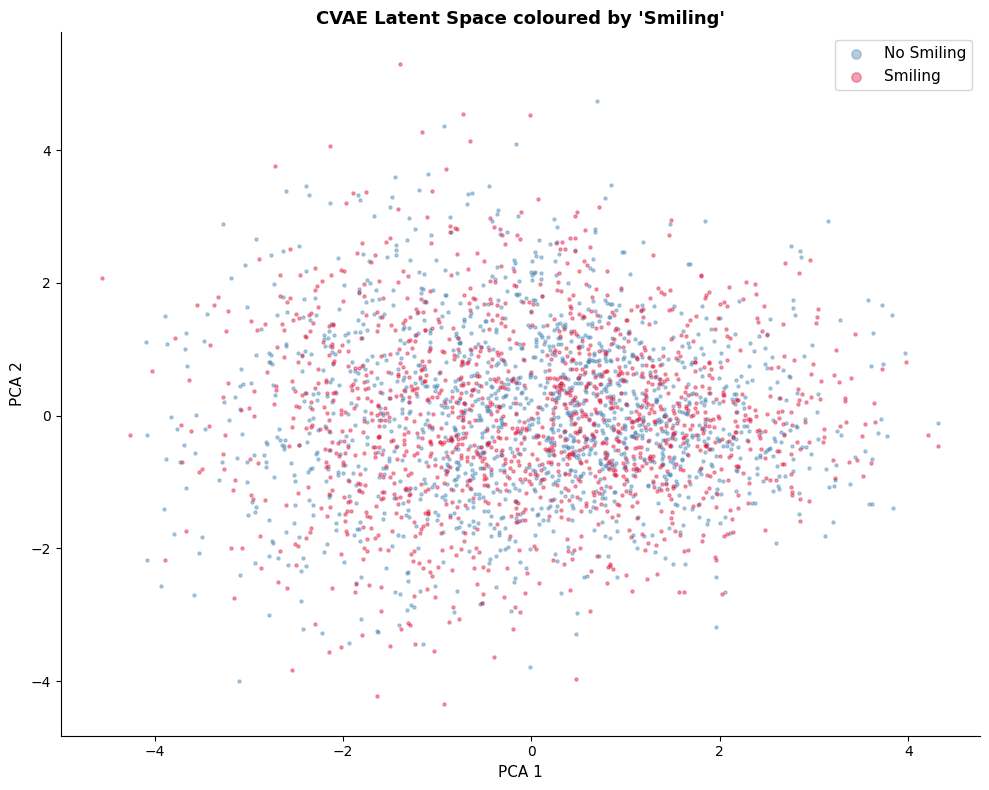

(array([[ 1.0065458 , -1.1421863 ],
        [-2.2612126 ,  0.70161706],
        [ 1.0008879 , -0.03643317],
        ...,
        [ 0.28594264,  2.0096972 ],
        [-1.0550907 , -0.1658672 ],
        [ 2.4248886 , -0.59998333]], dtype=float32),
 array([1., 1., 0., ..., 1., 1., 0.], dtype=float32))

In [14]:
# @title Latent space coloured by attribute {display-mode: "form"}
visualise_latent_space_celeba(cvae, X_test, attrs_test, CELEBA_ATTR_NAMES,
                              color_by="Smiling", n_viz=3000)

2D PCA explains 4.8% of latent variance


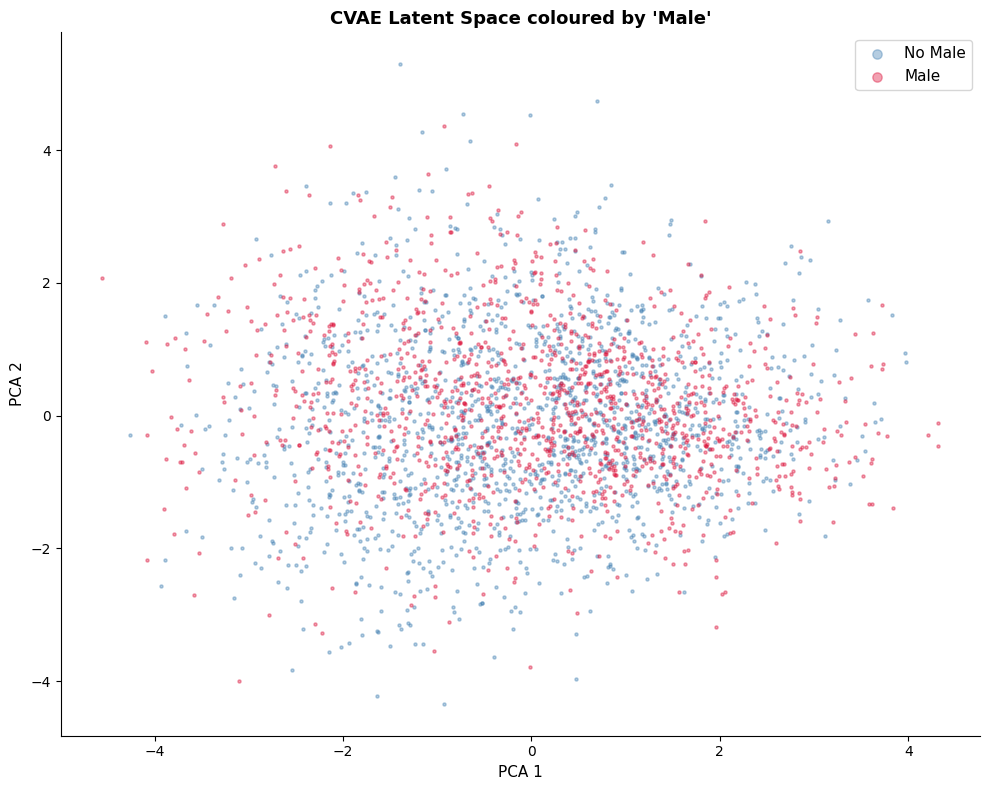

(array([[ 1.0065458 , -1.1421863 ],
        [-2.2612126 ,  0.70161706],
        [ 1.0008879 , -0.03643317],
        ...,
        [ 0.28594264,  2.0096972 ],
        [-1.0550907 , -0.1658672 ],
        [ 2.4248886 , -0.59998333]], dtype=float32),
 array([0., 1., 0., ..., 0., 0., 0.], dtype=float32))

In [15]:
# Try another attribute
visualise_latent_space_celeba(cvae, X_test, attrs_test, CELEBA_ATTR_NAMES,
                              color_by="Male", n_viz=3000)

### How to Read This

If the CVAE is well-trained, you should see **significant overlap** between the two groups — because the attribute information is in the condition, not in z. Some separation is normal (attributes correlate with style), but less than an unconditional model.

---
## Part 6: Interpolation and Attribute Manipulation

### Latent Interpolation

We can smoothly morph between two faces by interpolating their latent vectors.

---
### TODO 4 — Interpolate between two faces

Pick two test images. Try with `switch_attrs=False` (fixed attributes) and `switch_attrs=True` (attributes change at midpoint).

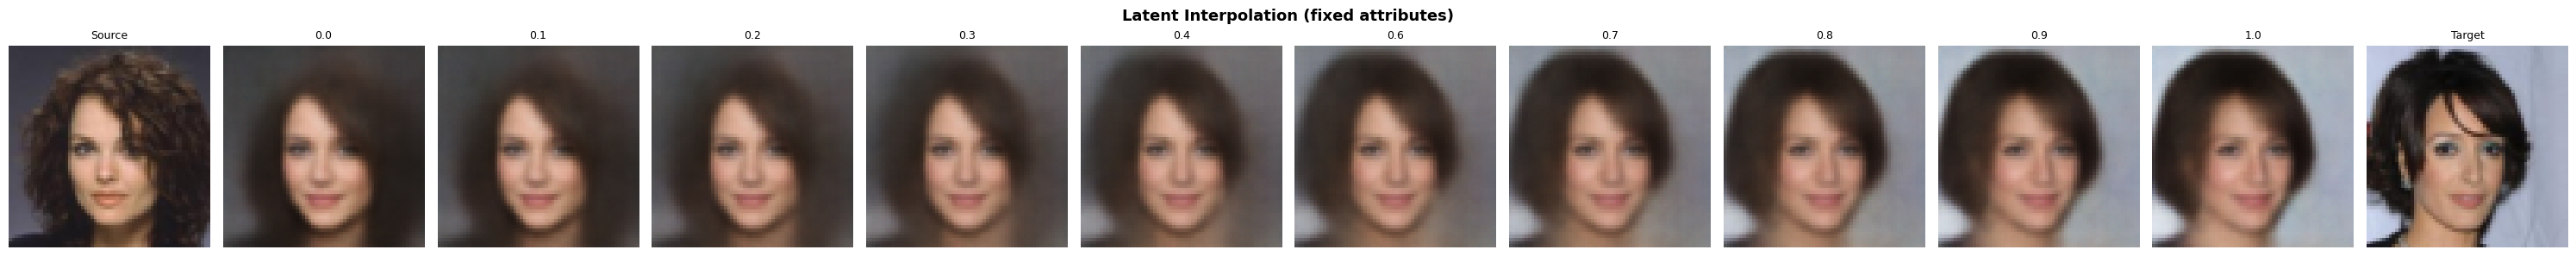

In [16]:
# SOLUTION: Fixed attributes
interpolate_latent_celeba(cvae, X_test, attrs_test, idx1=0, idx2=5, n_steps=10)

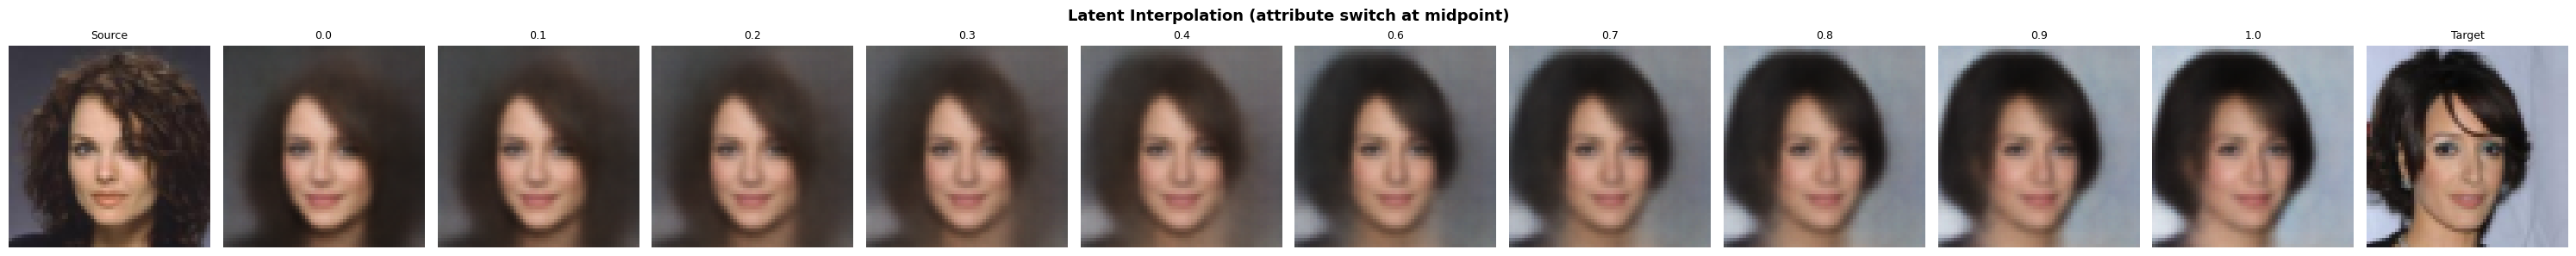

In [17]:
# SOLUTION: Attribute switch at midpoint
interpolate_latent_celeba(cvae, X_test, attrs_test, idx1=0, idx2=5,
                          n_steps=10, switch_attrs=True)

### Attribute Manipulation — The Fun Part!

This is unique to CelebA. We can take a real face, encode it, and decode with **modified attributes** — adding or removing a smile, glasses, etc. The latent z preserves the identity while the attributes change the appearance.

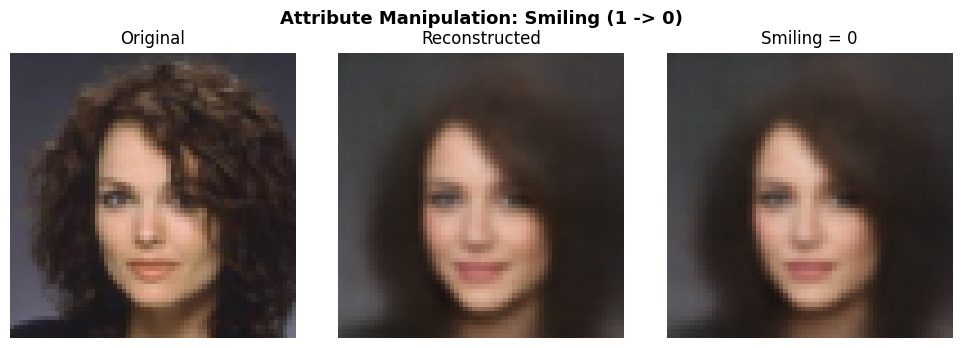

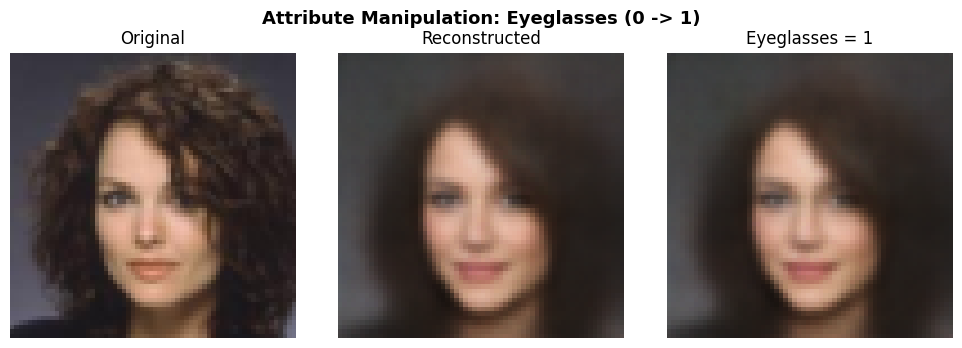

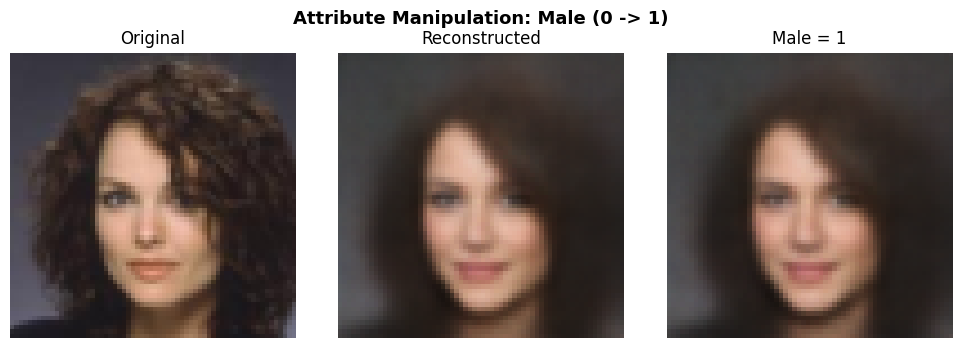

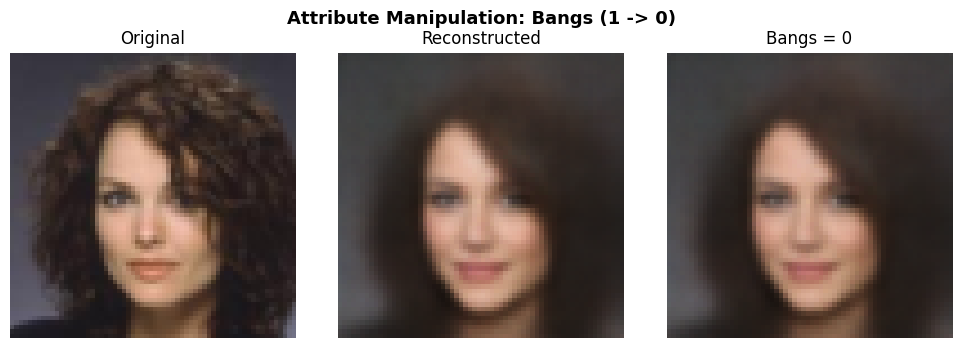

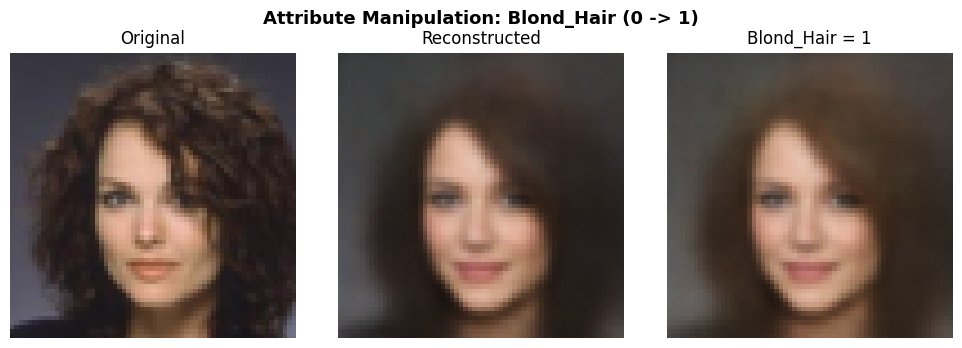

In [18]:
# Try manipulating different attributes on different faces
for attr in ["Smiling", "Eyeglasses", "Male", "Bangs", "Blond_Hair"]:
    manipulate_attribute(cvae, X_test, attrs_test, CELEBA_ATTR_NAMES,
                         idx=0, attr_to_change=attr)

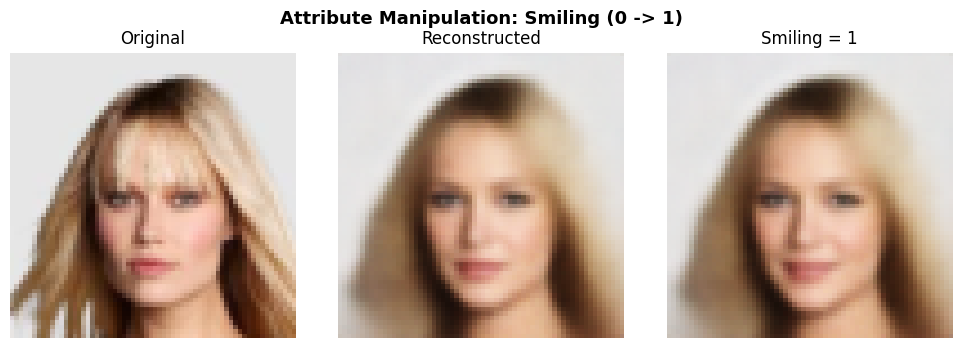

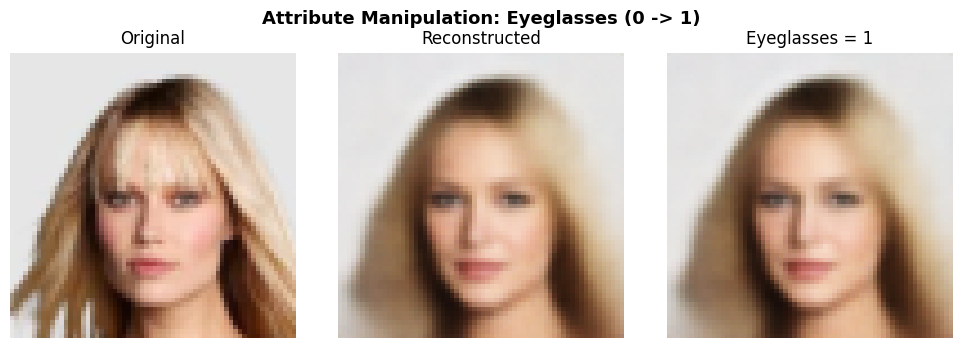

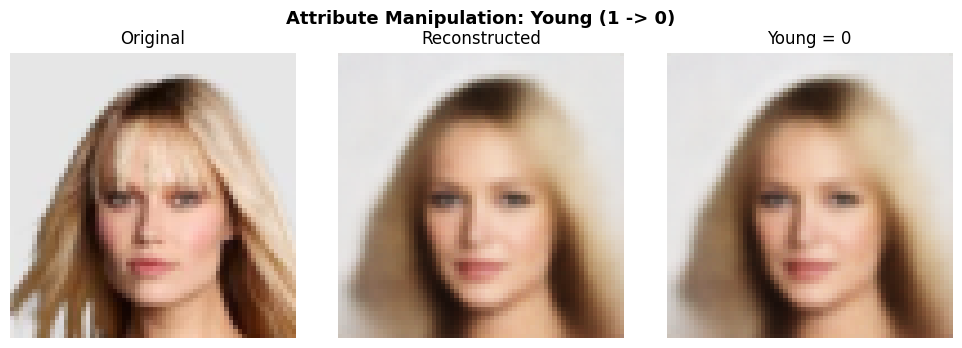

In [19]:
# Try on a different face
for attr in ["Smiling", "Eyeglasses", "Young"]:
    manipulate_attribute(cvae, X_test, attrs_test, CELEBA_ATTR_NAMES,
                         idx=10, attr_to_change=attr)

### Debrief

- **Fixed attributes:** the face smoothly morphs from source to target style while keeping the same attributes
- **Attribute switch:** the face structure morphs smoothly but attributes change abruptly at midpoint
- **Attribute manipulation:** the identity is roughly preserved while the specified attribute changes

This demonstrates the **disentanglement** between content (attributes) and style (z).

---
## Part 7: The Effect of Beta

| Beta | Reconstruction | Latent Space | Generation |
|---|---|---|---|
| Low (0.1) | Sharp, detailed | Irregular | May produce artifacts |
| Standard (1.0) | Good balance | Regular | Decent quality |
| High (5.0) | Blurry | Very regular | Diverse but fuzzy |

---
### TODO 5 — Experiment with different beta values

Train the CelebA CVAE with different beta values. For each, generate an attribute grid and compare.

In [20]:
# SOLUTION
test_combos = [
    {"Smiling": 1},
    {"Eyeglasses": 1},
    {"Male": 1, "Young": 1},
]

for beta_val in [0.1, 1.0, 5.0]:
    print(f"\n{'='*50}")
    print(f"Training with beta = {beta_val}")
    print(f"{'='*50}")
    model_beta = CelebAConvCVAE(latent_dim=LATENT_DIM).to(DEVICE)
    model_beta, _ = train_cvae_celeba(model_beta, cvae_loss, X_train, attrs_train,
                                      epochs=15, batch_size=64, lr=1e-3, beta=beta_val)
    generate_attribute_grid(model_beta, CELEBA_ATTR_NAMES, test_combos,
                            latent_dim=LATENT_DIM, n_per_row=6)


Training with beta = 0.1


KeyboardInterrupt: 

### Debrief

- **beta = 0.1**: sharper faces, but may show attribute leakage (e.g., "Smiling" might not always work)
- **beta = 1.0**: good balance of quality and attribute control
- **beta = 5.0**: blurry but very consistent attribute conditioning

The blurriness at high beta is more noticeable on faces than digits — this is the **rate-distortion trade-off** in action.

---
## Part 8: Evaluating Generation Quality

We train an attribute predictor on real CelebA images, then test it on generated images. If the predictor correctly identifies the attributes we conditioned on, the CVAE is generating attribute-faithful faces.

In [21]:
# @title Train attribute predictor and evaluate {display-mode: "form"}
print("Training attribute predictor on real CelebA images...")
predictor = train_attribute_predictor(CelebAAttributePredictor, X_train, attrs_train, epochs=10)

print("\nEvaluating CVAE-generated images...")
per_attr_acc = evaluate_generated_celeba(cvae, predictor, CELEBA_ATTR_NAMES,
                                         latent_dim=LATENT_DIM, n_samples=1000)

Training attribute predictor on real CelebA images...
  Predictor epoch 1/10 -- BCE: 0.3800


KeyboardInterrupt: 

### Debrief

Common attributes (Smiling, Male, Young) should have higher accuracy than rare ones (Bald, Wearing_Hat). The mean accuracy gives an overall picture of how well the CVAE respects conditioning.

---
## Summary

| Step | What You Did |
|---|---|
| Data exploration | Loaded CelebA with 40 binary attributes |
| Architecture | Built CelebAConvCVAE (43->64->128->256->512, latent=128) |
| TODO 1 | Implemented conditional_input, reparametrize, encode, decode, forward |
| TODO 2 | Implemented CVAE loss (BCE + beta x KL) — same as MNIST |
| Training | Trained on 30k faces with cosine LR schedule |
| Reconstruction | Measured per-attribute reconstruction quality |
| TODO 3 | Generated faces with specific attributes |
| Latent space | Visualised attribute (dis)entanglement |
| TODO 4 | Interpolated between faces, explored attribute switching |
| Attribute manipulation | Flipped attributes while preserving identity |
| TODO 5 | Investigated beta trade-off on faces |
| Evaluation | Tested attribute fidelity with a predictor |

### Key Takeaways
- The **same CVAE architecture** scales from MNIST to CelebA — only dimensions change
- CelebA uses **multi-label binary conditions** (40 attributes) vs MNIST's **one-hot classes** (10 digits)
- **Attribute manipulation** (encode, flip attribute, decode) is the CelebA CVAE's killer feature
- VAE face reconstructions are **blurry** — motivating GANs and diffusion models
- The **beta trade-off** is even more visible on complex data like faces